In [ ]:
# import library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve

In [ ]:
# load data
df = pd.read_csv('bank_churn_data.csv')
df.head()

,user_id,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
# data understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [ ]:
df.describe()

,user_id,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
df.isnull().sum()

,0
user_id,0
attrition_flag,0
customer_age,0
gender,0
dependent_count,0
education_level,0
marital_status,0
income_category,0
card_category,0
months_on_book,0


# Eksplorasi Data

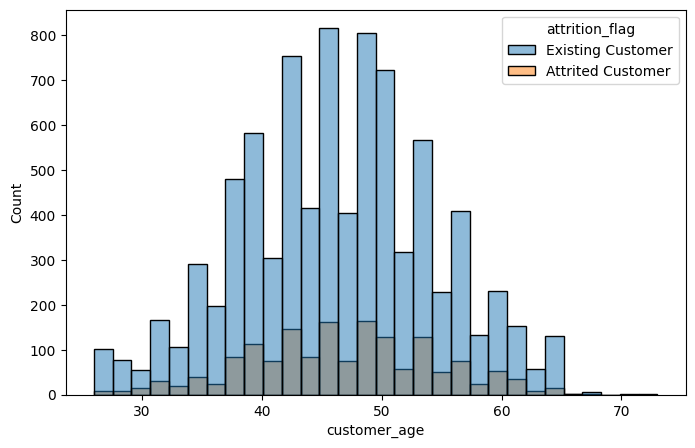

In [ ]:
# Distribusi usia vs Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='customer_age', hue='attrition_flag', bins=30)
plt.show()

## 💡 Insight:
Distribusi usia nasabah terlihat terkonsentrasi pada rentang 40–55 tahun. Jika dilihat berdasarkan churn, nasabah dengan status Attrited Customer cenderung memiliki usia yang sedikit lebih tinggi dibandingkan nasabah yang tetap bertahan.

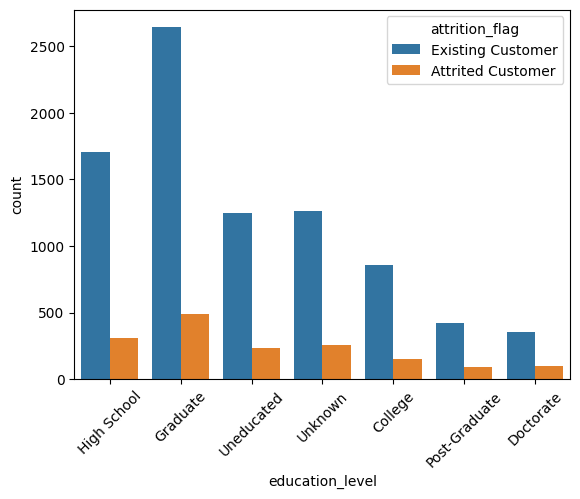

In [ ]:
# Education vs Churn
sns.countplot(data=df, x='education_level', hue='attrition_flag')
plt.xticks(rotation=45)
plt.show()

##💡 Insight:
Nasabah dengan tingkat pendidikan Graduate mendominasi jumlah total customer, baik yang churn maupun tidak. Namun, jika dilihat proporsinya, churn terjadi di hampir semua tingkat pendidikan tanpa perbedaan yang terlalu mencolok.

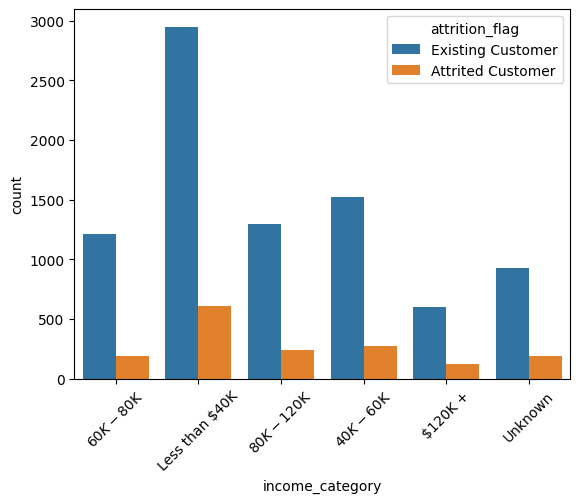

In [ ]:
# Income vs Churn
sns.countplot(data=df, x='income_category', hue='attrition_flag')
plt.xticks(rotation=45)
plt.show()

##💡 Insight:
Nasabah dengan kategori income < $40K memiliki jumlah churn paling tinggi secara absolut. Namun kategori income lain juga tetap menunjukkan adanya churn.

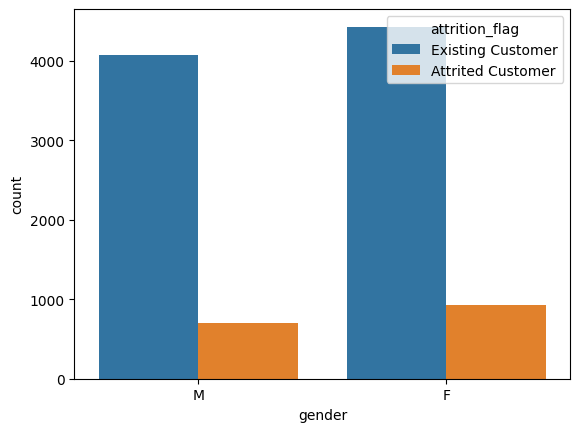

In [ ]:
# Gender vs Churn
sns.countplot(data=df, x='gender', hue='attrition_flag')
plt.show()

##💡 Insight:
Jumlah nasabah perempuan sedikit lebih banyak dibanding laki-laki. Selain itu, jumlah churn pada perempuan juga terlihat lebih tinggi dibandingkan laki-laki.

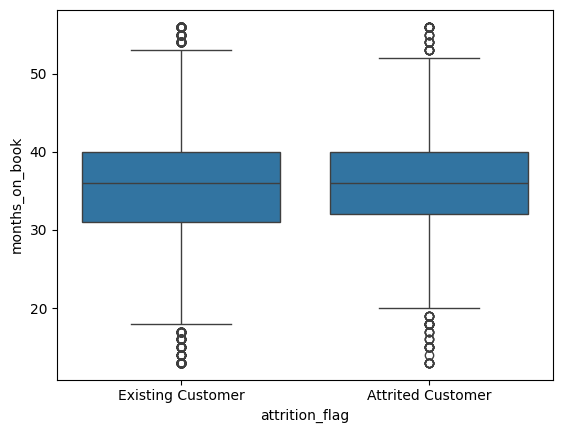

In [ ]:
# Tenure (months_on_book) vs Churn
sns.boxplot(data=df, x='attrition_flag', y='months_on_book')
plt.show()

## 💡 Insight:
Distribusi tenure antara customer churn dan tidak churn relatif mirip, namun terlihat bahwa:
Customer churn cenderung memiliki tenure yang sedikit lebih rendah

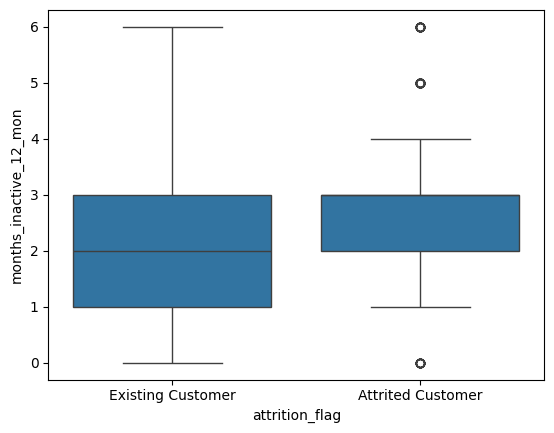

In [ ]:
# Interaksi inactive vs Churn
sns.boxplot(data=df, x='attrition_flag', y='months_inactive_12_mon')
plt.show()

##💡 Insight:
Nasabah yang churn memiliki nilai months_inactive_12_mon yang lebih tinggi dibandingkan nasabah yang tidak churn.

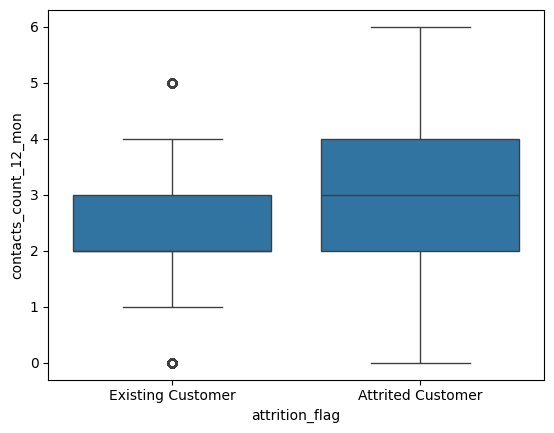

In [ ]:
# Interaksi contacts vs Churn
sns.boxplot(data=df, x='attrition_flag', y='contacts_count_12_mon')
plt.show()

## 💡 Insight:
Nasabah yang churn memiliki jumlah kontak dengan bank yang lebih tinggi dibandingkan yang tidak churn.

# Pemodelan Machine Learning

In [ ]:
# drop kolom yang tidak relevan
df = df.drop(['user_id'], axis=1)

In [ ]:
# encode target
df['attrition_flag'] = df['attrition_flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [ ]:
# one hot encoding
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# split data
from sklearn.model_selection import train_test_split

X = df.drop('attrition_flag', axis=1)
y = df['attrition_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 📌 Dummy Classifier (baseline)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

y_base = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_base))

Baseline Accuracy: 0.8395853899308984


In [ ]:
# Model Utama: Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# prediksi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
# teknik validasi
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

print("CV ROC-AUC:", cv_scores.mean())

CV ROC-AUC: 0.924049105315591


In [ ]:
# evaluasi
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

Accuracy: 0.8998025666337611
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1701
           1       0.77      0.54      0.63       325

    accuracy                           0.90      2026
   macro avg       0.84      0.75      0.79      2026
weighted avg       0.89      0.90      0.89      2026

ROC-AUC: 0.9165938588160811


In [ ]:
print("Baseline Accuracy:", accuracy_score(y_test, y_base))
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.8395853899308984
Model Accuracy: 0.8998025666337611


## 💡 Insight:
Model baseline menghasilkan akurasi sebesar 83.95% dengan hanya memprediksi kelas mayoritas, yaitu nasabah yang tidak churn. Meskipun nilai akurasi terlihat cukup tinggi, model ini tidak memiliki kemampuan untuk mengidentifikasi nasabah yang benar-benar churn.
Model Logistic Regression yang dibangun menunjukkan peningkatan performa dengan akurasi sebesar 89.98% dan nilai ROC-AUC sebesar 0.91, yang mengindikasikan kemampuan model yang sangat baik dalam membedakan antara nasabah yang churn dan tidak churn.
Selain itu, hasil cross-validation dengan nilai ROC-AUC sebesar 0.92 menunjukkan bahwa model memiliki performa yang stabil dan tidak mengalami overfitting.

# Evaluasi Model

## ✍️ Insight classification report:
Berdasarkan classification report:
- Model memiliki performa yang sangat baik pada kelas non-churn (0) dengan precision dan recall yang tinggi.

- Untuk kelas churn (1):

Precision cukup baik (~0.77)

Recall masih lebih rendah (~0.54)

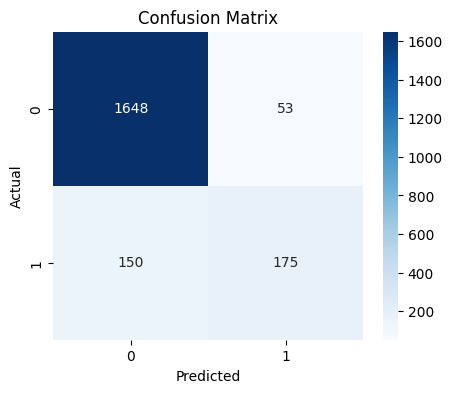

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ✍️ Insight
Confusion matrix menunjukkan bahwa model mampu mengklasifikasikan sebagian besar nasabah dengan benar, khususnya pada kelas non-churn. Namun, masih terdapat sejumlah nasabah churn yang tidak terdeteksi (false negative sebanyak 150)

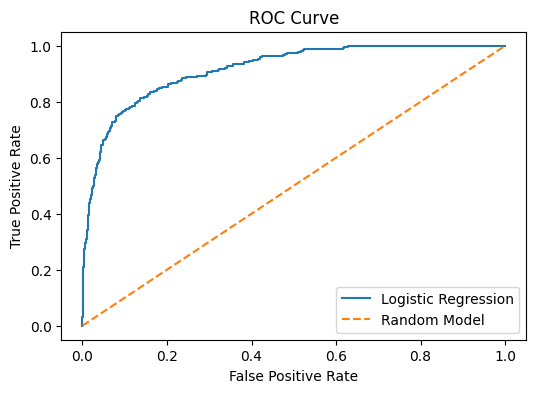

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],'--', label='Random Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## ✍️ Insight
Berdasarkan ROC Curve, model Kogistic Regression memiliki kurva yang berada jauh di atas garis diagonal (random odel) yang menunjukkan bahwa model memiliki kemampuan klasifikasi yang jauh lebih baik dibandingkan tebakan acak

# Analis Interpretabilitas Model

In [ ]:
# Feature Imprtance (Koefisien Logistic Regression)
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef = coef.sort_values(by='Coefficient', ascending=False)
coef.head(10)

,Feature,Coefficient
10,total_trans_amt,1.559951
5,contacts_count_12_mon,0.570889
4,months_inactive_12_mon,0.519557
1,dependent_count,0.235582
22,marital_status_Single,0.131473
29,card_category_Gold,0.117782
31,card_category_Silver,0.083197
23,marital_status_Unknown,0.075796
18,education_level_Post-Graduate,0.057275
15,education_level_Doctorate,0.056921


In [ ]:
# melihat yang berpengaruh ke churn
coef.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
10,total_trans_amt,1.559951
5,contacts_count_12_mon,0.570889
4,months_inactive_12_mon,0.519557
1,dependent_count,0.235582
22,marital_status_Single,0.131473
29,card_category_Gold,0.117782
31,card_category_Silver,0.083197
23,marital_status_Unknown,0.075796
18,education_level_Post-Graduate,0.057275
15,education_level_Doctorate,0.056921


In [ ]:
# melihat yang menurunkan churn
coef.sort_values(by='Coefficient', ascending=True).head(10)

,Feature,Coefficient
11,total_trans_ct,-2.743786
3,total_relationship_count,-0.741539
7,total_revolving_bal,-0.724200
12,total_ct_chng_q4_q1,-0.671926
14,gender_M,-0.428656
27,income_category_Less than $40K,-0.321005
24,income_category_$40K - $60K,-0.304959
28,income_category_Unknown,-0.216925
25,income_category_$60K - $80K,-0.201481
21,marital_status_Married,-0.158777


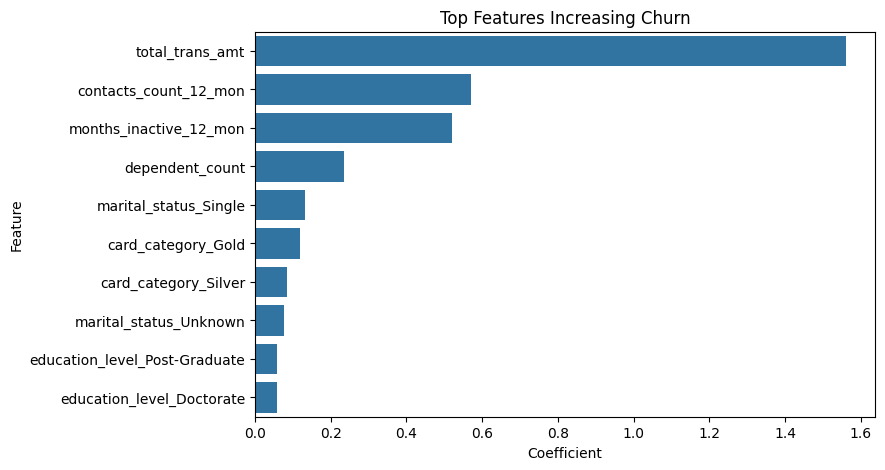

In [ ]:
# visualisasi feature importance
top_features = coef.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title('Top Features Increasing Churn')
plt.show()

## ✍️ Insight Utama
Berdasarkan hasil interpretasi model, faktor utama yang mempengaruhi churn adalah perilaku nasabah, bukan hanya karakteristiik demografis.

Nasabah yang kurang aktif, sering mengalami interaksi yang berpotensi negatif dengan bank, serta memiliki ekspetasi tinggi terhadao layanan cenderung lebih berisiko untuk churn

Sebaliknya, nasabah yang aktif bertransaksi dan memiliki hubungan yang lebih kuat dengan bank cenderung lebih loyal.

# ⁉️ Pertanyaan

### Soal 1. Distribusi usia vs churn
terlihat dari distribusi, mayoritas nasabah ada direntang usia sekitar 40-55 tahun. Tapi yang menarik, nasabah dengan usia yang lebih tinggi cenderung punya kemungkinan churn yang lebih besar

Artinya, makin bertambah usia, kemungkinan mereka untuk berhenti menggunakan layanan juga ikut meningkat. BIda jadi karena kebutuhan mereka berubah atau ekspetasi terhadap layanan jadi lebih tinggi

### Soal 2. Education & Income terhadap churn
Dari data terlihat kalau tingkat pendidikan dan income memang saling berkaitan biasanya yang pendidikannya lebih tinggi punya income lebih besar

Tapi jika dikaitkan dengan churn, ternyata dua faktor ini tidak perlu dominan. Churn terjadi dihampir semua kategori baik income rendah maupun tinggi



### Soal 3. Gender vs Churn
Terlihat dari gender memang ada sedikit perbedaan jumlah churn antara laki-laki dan perempuan. Tapi perbedaanya tidak terlalu signifikan.

Jadi, gender bukan faktor utama yang menentukan apakah nasabah akan churn atau tidak tapi teteap bisa jadi tambahan informasi untuk segmentasi

### Soal 4. Lama menjadi nasabah vs churn
Terlihat cukup jelas bahwa nasabah yang sudah lama bergabung cenderung lebih loyal dan kecil kemungkinan untuk churn

Sebaliknya, nasabah yang masih baru justru lebih berisiko untuk churn. Ini masuk akal karena mereka belum punya keterikatan yang kuat dengan layanan bank

### Soal 5. Interaksi dengan bank vs churn
Dari hasil analisis, nasabah yang jarang aktif justru punya kemungkinan churn yang lebih tinggi. Selain itu, nasabah yang sering kontak dengan bank juga cenderung lebih banyak yang churn

### Soal 6. Model ML & Evaluasi
Model yang digunakan adalah Logistic Regression karena model ini cukup sederhana tapi bisa dijelaskan dengan jelas.

Dari hasil evaluasi, performa model cukup baik, dengan nilai ROC-AUC sekitar
0.91. Ini berarti model sudah cukup bagus dalam membedakan mana nasabah yang kemungkinan churn dan mana yang tidak.

# ⁉️ Reflection Question

1. EDA itu penting karena dari situ kita bisa ngerti pola data sebelum bikin model. Dari analisis yang dilakukan, terlihat kalau faktor perilaku seperti tingkat aktivitas dan frekuensi transaksi lebih berpengaruh ke churn dibanding faktor demografis seperti pendidikan atau gender. Misalnya, nasabah yang jarang aktif atau sering tidak bertransaksi cenderung lebih mudah churn. Insight seperti ini membantu kita memilih fitur yang benar-benar relevan, jadi model yang dibangun lebih masuk akal dan tidak sekadar mengandalkan semua variabel.


2. Model prediksi churn yang akurat jauh lebih menguntungkan dibanding hanya pakai asumsi sederhana. Dengan model, perusahaan bisa fokus ke nasabah yang benar-benar berisiko churn, jadi strategi retensi lebih tepat sasaran. Dampaknya, penggunaan anggaran jadi lebih efisien karena tidak perlu memberi promo ke semua nasabah, dan peluang keberhasilan juga lebih tinggi. Ini akhirnya bisa meningkatkan ROI karena keputusan yang diambil sudah berbasis data, bukan sekadar perkiraan.
